In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## Ridge Regression Class

── Training Results ──────────────────────
  MSE : 2642.1096
  R²  : 0.7278

── Test Results ──────────────────────────
  MSE : 2406.4028
  R²  : 0.7246

── Learned Parameters ────────────────────
  Weights : [ 3.25   5.795 32.744  8.743 33.567]
  Bias    : 10.6228


C:\Users\muham\AppData\Local\Temp\ipykernel_26088\1558740041.py:74: RuntimeWarning: overflow encountered in scalar multiply
  loss = mse + self.lambda_ * np.sum(self.weights ** 2)
D:\Complete ML\Data Science\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\muham\AppData\Local\Temp\ipykernel_26088\1558740041.py:73: RuntimeWarning: overflow encountered in square
  mse  = np.mean(residuals ** 2)
C:\Users\muham\AppData\Local\Temp\ipykernel_26088\1558740041.py:74: RuntimeWarning: overflow encountered in square
  loss = mse + self.lambda_ * np.sum(self.weights ** 2)
D:\Complete ML\Data Science\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\muham\AppData\Local\Temp\ipykernel_26088\1558740041.py:63: RuntimeWarning: overflow encountered in multiply
  dw 

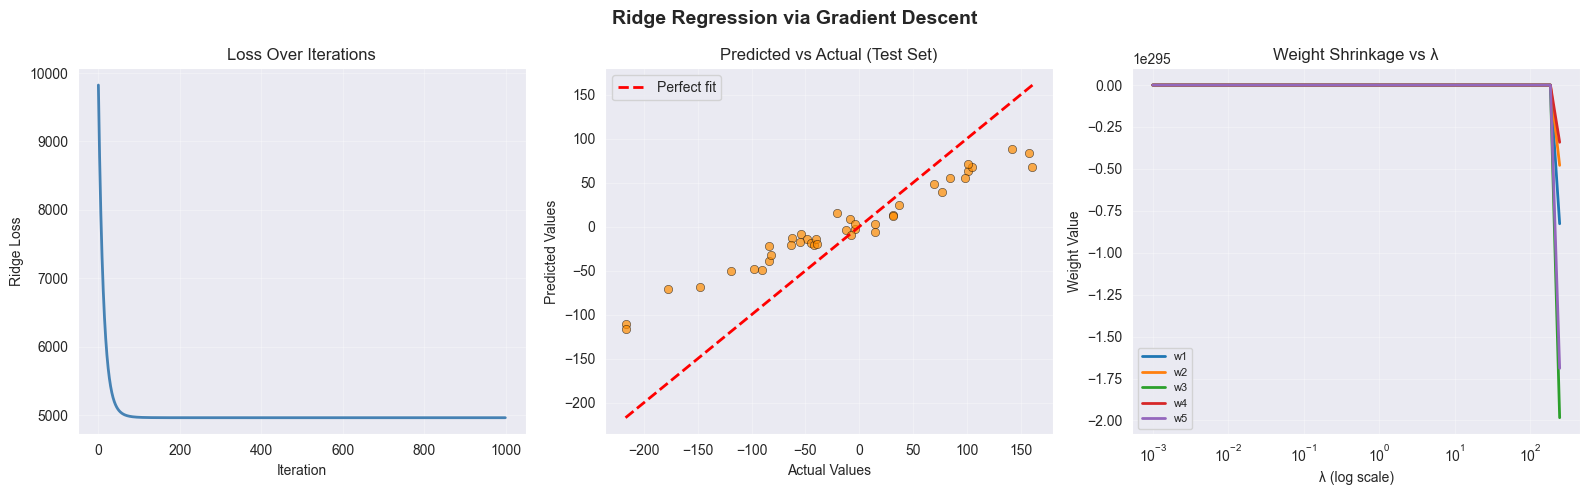


Plot saved → ridge_regression_results.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ─────────────────────────────────────────────
# 1. Ridge Regression Class
# ─────────────────────────────────────────────

class RidgeRegressionGD:
    """
    Ridge Regression solved via Gradient Descent.

    Loss = (1/n) * ||Xw - y||² + λ * ||w||²
    Gradient w.r.t w  = (2/n) * Xᵀ(Xw - y) + 2λw
    Gradient w.r.t b  = (2/n) * sum(Xw - y)   ← bias is NOT regularized
    """

    def __init__(self, alpha=0.01, lambda_=1.0, n_iterations=1000):
        """
        Parameters
        ----------
        alpha       : float  – learning rate. Step size for each GD update
        lambda_     : float  – regularization strength (λ)
        n_iterations: int    – number of gradient descent steps
        weight / bias :  Set to none - Initialized properly in fit()
        """
        self.alpha        = alpha
        self.lambda_      = lambda_
        self.n_iterations = n_iterations
        self.weights      = None   # model weights (slopes)
        self.bias         = None   # model bias (intercept)
        self.loss_history = []     # track loss over iterations for plotting

    def fit(self, X, y):
        """
        Train the model using gradient descent.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
        y : ndarray of shape (n_samples,)
        """
        n_samples, n_features = X.shape

        # Initialize weights to zeros; bias to zero
        self.weights = np.zeros(n_features)
        self.bias    = 0.0   # (bias is never regularized)

        for i in range(self.n_iterations):

            # ── Forward pass: compute predictions
            # For each sample it computes w1x1 + w2x2 + ... + wnx
            y_pred = X @ self.weights + self.bias   # shape: (n_samples,)

            # ── Compute residuals
            residuals = y_pred - y                  # shape: (n_samples,)

            # ── Gradients
            # dL/dw = (2/n) * Xᵀ·residuals  +  2λ·w   (L2 penalty on weights)
            dw = (2 / n_samples) * (X.T @ residuals) + 2 * self.lambda_ * self.weights

            # dL/db = (2/n) * sum(residuals)            (bias not regularized)
            db = (2 / n_samples) * np.sum(residuals)

            # ── Parameter update (gradient descent step)
            self.weights -= self.alpha * dw
            self.bias    -= self.alpha * db

            # ── Record loss for diagnostics
            mse  = np.mean(residuals ** 2)
            loss = mse + self.lambda_ * np.sum(self.weights ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        """Return predictions for input X."""
        return X @ self.weights + self.bias

    def score(self, X, y):
        """Return R² score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot


# 2. Generate & Prepare Data


np.random.seed(42)

# Synthetic regression dataset: 200 samples, 5 features, some noise
X, y = make_regression(n_samples=200, n_features=5, noise=20, random_state=42)

# Split into 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features — critical for gradient descent to converge smoothly
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train only
X_test  = scaler.transform(X_test)        # apply same scale to test



# 3. Train Model
model = RidgeRegressionGD(
    alpha=0.01,        # learning rate
    lambda_=1.0,       # regularization strength
    n_iterations=1000  # gradient descent steps
)

model.fit(X_train, y_train)


# 4. Evaluate

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("── Training Results ──────────────────────")
print(f"  MSE : {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"  R²  : {r2_score(y_train, y_pred_train):.4f}")

print("\n── Test Results ──────────────────────────")
print(f"  MSE : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"  R²  : {r2_score(y_test, y_pred_test):.4f}")

print("\n── Learned Parameters ────────────────────")
print(f"  Weights : {np.round(model.weights, 3)}")
print(f"  Bias    : {model.bias:.4f}")


# ─────────────────────────────────────────────
# 5. Plots
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ridge Regression via Gradient Descent", fontsize=14, fontweight='bold')

# Plot 1 – Loss Curve
axes[0].plot(model.loss_history, color='steelblue', linewidth=2)
axes[0].set_title("Loss Over Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Ridge Loss")
axes[0].grid(True, alpha=0.3)

# Plot 2 – Predicted vs Actual (test set)
axes[1].scatter(y_test, y_pred_test, alpha=0.7, color='darkorange', edgecolors='k', linewidth=0.4)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect fit')
axes[1].set_title("Predicted vs Actual (Test Set)")
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 – Effect of λ on weights
lambdas       = np.logspace(-3, 3, 50)   # 0.001 → 1000
weight_matrix = []

for lam in lambdas:
    m = RidgeRegressionGD(alpha=0.01, lambda_=lam, n_iterations=500)
    m.fit(X_train, y_train)
    weight_matrix.append(m.weights)

weight_matrix = np.array(weight_matrix)   # shape: (50, 5)

for j in range(weight_matrix.shape[1]):
    axes[2].plot(lambdas, weight_matrix[:, j], linewidth=2, label=f'w{j+1}')

axes[2].set_xscale('log')
axes[2].set_title("Weight Shrinkage vs λ")
axes[2].set_xlabel("λ (log scale)")
axes[2].set_ylabel("Weight Value")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ridge_regression_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved → ridge_regression_results.png")